# Frozen DistilBERT — WELFake Training & Live RSS Classification

**What this notebook does:**
- Loads pre-trained `distilbert-base-uncased` with all transformer layers **frozen**
- Only the classification head (Linear 768→2) is trained on WELFake
- Classifies live news from 8 RSS feeds from the past 24 hours
- Compares P(fake) distribution against the fully fine-tuned model

**Why frozen?**  
The pre-trained weights (from Wikipedia + BookCorpus) are preserved exactly.  
Only the final classification layer adapts to WELFake. This prevents the model  
from overfitting to WELFake's publisher fingerprints and scraping artifacts,  
at the cost of lower in-distribution accuracy.

**Label convention:** 0 = Real, 1 = Fake

## 0. Install & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install feedparser transformers torch scikit-learn pandas numpy tqdm -q

import os
import numpy as np
import pandas as pd
import feedparser
import torch
import torch.nn as nn
from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

WELFAKE_CSV = '/content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/WELFake_Dataset.csv'
SAVE_DIR    = '/content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/distilbert_frozen'
os.makedirs(SAVE_DIR, exist_ok=True)

# Training config
MAX_LEN    = 256
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-4   # higher LR than full fine-tuning — only head is trained
HOURS_BACK = 24

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
Device: cuda


## 1. Load WELFake

In [3]:
df = pd.read_csv(WELFAKE_CSV)
df = df.iloc[:, 1:].dropna(subset=['text'])
df['title']   = df['title'].fillna('')
df['content'] = df['title'] + ' ' + df['text']
# 0=Real, 1=Fake

X = df['content'].values
y = df['label'].values

# No test split needed — we only train here and evaluate on live RSS
# But keep a small validation set to monitor training
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.05, random_state=SEED, stratify=y
)
print(f'WELFake: {len(df):,} total  |  0=Real, 1=Fake')
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}')
print(f'Train — real: {(y_train==0).sum():,}  fake: {(y_train==1).sum():,}')

# Sanity check
print('\nSample Real (label=0):')
print(' ', X_train[y_train==0][0][:120])
print('Sample Fake (label=1):')
print(' ', X_train[y_train==1][0][:120])

WELFake: 72,095 total  |  0=Real, 1=Fake
Train: 68,490  Val: 3,605
Train — real: 33,276  fake: 35,214

Sample Real (label=0):
  Indonesia court rejects petition to bar consensual sex outside marriage JAKARTA (Reuters) - Indonesia s constitutional c
Sample Fake (label=1):
  Don’t Root, Root, Root for the Racist, Red-Face Team from Cleveland Don’t Root, Root, Root for the Racist, Red-Face Team


## 2. Dataset Class

In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')


class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2141  Val batches: 113


## 3. Frozen DistilBERT Model

The transformer backbone is loaded and immediately frozen — `requires_grad=False`  
on all parameters. Only the classification head is trainable.

In [5]:
class FrozenDistilBertClassifier(nn.Module):
    """
    DistilBERT with all transformer layers frozen.
    Only the classification head is trained.

    Architecture:
      DistilBERT (frozen) → CLS token [768-dim] → Dropout → Linear(768, 2)

    The pre-trained weights from Wikipedia + BookCorpus are preserved
    exactly. Training only adjusts the final linear layer.
    """
    def __init__(self, dropout=0.3):
        super().__init__()

        # Load pre-trained backbone
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Freeze ALL transformer parameters
        for param in self.distilbert.parameters():
            param.requires_grad = False

        # Trainable classification head only
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):
        # Frozen backbone — no gradient computation here
        with torch.no_grad():
            outputs = self.distilbert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        # CLS token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)
        return logits


model = FrozenDistilBertClassifier(dropout=0.3).to(device)

# Verify only the head is trainable
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}  '
      f'({trainable_params/total_params:.1%} of total)')
print(f'Frozen parameters:    {total_params - trainable_params:,}')
print()
print('Trainable layers:')
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  {name}: {param.shape}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     66,364,418
Trainable parameters: 1,538  (0.0% of total)
Frozen parameters:    66,362,880

Trainable layers:
  classifier.weight: torch.Size([2, 768])
  classifier.bias: torch.Size([2])


## 4. Train

In [6]:
criterion = nn.CrossEntropyLoss()
# Only pass trainable parameters to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} train'):
        optimizer.zero_grad()
        logits = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        loss = criterion(logits, batch['label'].to(device))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validate ────────────────────────────────────────────────────────────────
    model.eval()
    val_loss  = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} val',
                          leave=False):
            logits = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            loss = criterion(logits, batch['label'].to(device))
            val_loss += loss.item()
            preds = torch.softmax(logits, dim=-1).argmax(dim=-1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(batch['label'].numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = accuracy_score(val_labels, val_preds)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS}  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={avg_val_loss:.4f}  '
          f'val_acc={val_acc:.4f}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   os.path.join(SAVE_DIR, 'frozen_distilbert_best.pt'))
        print(f'  → Best model saved (val_acc={val_acc:.4f})')

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')

Epoch 1/3 train:   0%|          | 0/2141 [00:00<?, ?it/s]

Epoch 1/3 val:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 1/3  train_loss=0.3917  val_loss=0.3275  val_acc=0.8571
  → Best model saved (val_acc=0.8571)


Epoch 2/3 train:   0%|          | 0/2141 [00:00<?, ?it/s]

Epoch 2/3 val:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 2/3  train_loss=0.3117  val_loss=0.2997  val_acc=0.8688
  → Best model saved (val_acc=0.8688)


Epoch 3/3 train:   0%|          | 0/2141 [00:00<?, ?it/s]

Epoch 3/3 val:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 3/3  train_loss=0.2962  val_loss=0.2857  val_acc=0.8735
  → Best model saved (val_acc=0.8735)

Training complete. Best val accuracy: 0.8735


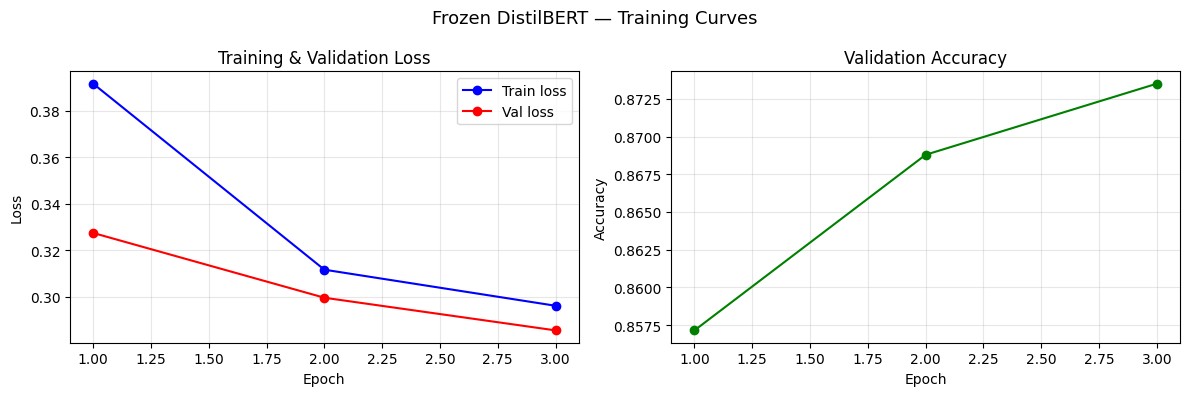

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss'); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'], 'g-o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(alpha=0.3)

plt.suptitle('Frozen DistilBERT — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Load Best Checkpoint

In [8]:
model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, 'frozen_distilbert_best.pt'),
               map_location=device)
)
model.eval()
print('Best checkpoint loaded.')

Best checkpoint loaded.


## 6. Inference Function

In [9]:
def classify_texts(texts, model, tokenizer, device,
                   max_len=MAX_LEN, batch_size=BATCH_SIZE):
    """
    Returns np.ndarray (n, 2).
    Column 0 = P(Real), Column 1 = P(Fake).
    Verify direction with the sanity check below before trusting results.
    """
    all_probs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch  = list(texts[i:i+batch_size])
            inputs = tokenizer(
                batch, max_length=max_len, padding='max_length',
                truncation=True, return_tensors='pt'
            ).to(device)
            logits = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)


# ── Sanity check: verify output column direction ──────────────────────────────
real_samples = list(X_train[y_train == 0][:3])
fake_samples = list(X_train[y_train == 1][:3])

real_probs = classify_texts(real_samples, model, tokenizer, device)
fake_probs = classify_texts(fake_samples, model, tokenizer, device)

print('Real articles (label=0):')
for p, t in zip(real_probs, real_samples):
    print(f'  col0={p[0]:.3f}  col1={p[1]:.3f}  |  {t[:80]}')

print('\nFake articles (label=1):')
for p, t in zip(fake_probs, fake_samples):
    print(f'  col0={p[0]:.3f}  col1={p[1]:.3f}  |  {t[:80]}')

# Auto-detect which column is fake
avg_real_col0 = real_probs[:, 0].mean()
if avg_real_col0 > 0.5:
    REAL_COL, FAKE_COL = 0, 1
else:
    REAL_COL, FAKE_COL = 1, 0

print(f'\nAuto-detected: REAL_COL={REAL_COL}, FAKE_COL={FAKE_COL}')
print('Verify this matches the output above.')

Real articles (label=0):
  col0=0.959  col1=0.041  |  Indonesia court rejects petition to bar consensual sex outside marriage JAKARTA 
  col0=0.994  col1=0.006  |  EU's Juncker says ready to retaliate if needed over new U.S. sanctions on Russia
  col0=0.995  col1=0.005  |  EU leaders to call for end to North Korea's weapons program: draft BRUSSELS (Reu

Fake articles (label=1):
  col0=0.425  col1=0.575  |  Don’t Root, Root, Root for the Racist, Red-Face Team from Cleveland Don’t Root, 
  col0=0.017  col1=0.983  |  WATCH: TOP 5 VIDEOS The Leftist Media Doesn’t Want You to See Of KID ROCK Giving
  col0=0.308  col1=0.692  |  Memo to Trump: 'Action This Day!'   => 
“In victory, magnanimity!” said Winston 

Auto-detected: REAL_COL=0, FAKE_COL=1
Verify this matches the output above.


## 7. Fetch RSS News & Classify

In [10]:
RSS_FEEDS = {
    'reuters_world':  'http://feeds.reuters.com/Reuters/worldNews',
    'reuters_top':    'http://feeds.reuters.com/reuters/topNews',
    'bbc_world':      'http://feeds.bbci.co.uk/news/world/rss.xml',
    'guardian_world': 'https://www.theguardian.com/world/rss',
    'ap_news':        'https://feeds.feedburner.com/AssociatedPressTopNews',
    'nyt_world':      'https://rss.nytimes.com/services/xml/rss/nyt/World.xml',
    'aljazeera':      'https://www.aljazeera.com/xml/rss/all.xml',
    'npr_news':       'https://feeds.npr.org/1001/rss.xml',
}


def fetch_rss(feeds, hours_back=24):
    articles    = []
    cutoff_time = datetime.now() - timedelta(hours=hours_back)
    for source, url in feeds.items():
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries[:25]:
                pub_time = (
                    datetime(*entry.published_parsed[:6])
                    if hasattr(entry, 'published_parsed') else datetime.now()
                )
                if pub_time < cutoff_time:
                    continue
                content = entry.title + ' ' + entry.get('summary', '')
                articles.append({
                    'source':    source,
                    'title':     entry.title,
                    'content':   content,
                    'published': pub_time,
                    'word_count': len(content.split())
                })
        except Exception as e:
            print(f'Error fetching {source}: {e}')
    return articles


print('Fetching RSS articles...')
articles = fetch_rss(RSS_FEEDS, hours_back=HOURS_BACK)
print(f'Fetched {len(articles)} articles from the past {HOURS_BACK}h')
print()
print('By source:')
from collections import Counter
for source, count in Counter(a['source'] for a in articles).items():
    avg_words = np.mean([a['word_count'] for a in articles if a['source'] == source])
    print(f'  {source:<20} {count:>3} articles  avg {avg_words:.0f} words')

Fetching RSS articles...
Fetched 95 articles from the past 24h

By source:
  bbc_world             20 articles  avg 29 words
  guardian_world        15 articles  avg 109 words
  nyt_world             25 articles  avg 33 words
  aljazeera             25 articles  avg 27 words
  npr_news              10 articles  avg 41 words


In [11]:
print('Classifying articles...')
contents = [a['content'] for a in articles]
probs    = classify_texts(contents, model, tokenizer, device)

for i, article in enumerate(articles):
    article['p_fake'] = float(probs[i, FAKE_COL])
    article['p_real'] = float(probs[i, REAL_COL])
    article['pred']   = 'FAKE' if article['p_fake'] > 0.5 else 'REAL'

results_df = pd.DataFrame(articles)
print(f'Done. {len(results_df)} articles classified.')
print(f"Predicted fake: {(results_df['pred']=='FAKE').sum()}")
print(f"Predicted real: {(results_df['pred']=='REAL').sum()}")
print(f"Mean P(fake):   {results_df['p_fake'].mean():.3f}")

Classifying articles...
Done. 95 articles classified.
Predicted fake: 30
Predicted real: 65
Mean P(fake):   0.338


## 8. Results

In [12]:
# ── Per-source summary ────────────────────────────────────────────────────────
print('='*65)
print('FROZEN DISTILBERT — RSS CLASSIFICATION RESULTS')
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('='*65)

print(f"\n{'Source':<20} {'Articles':>8} {'Mean P(fake)':>14} "
      f"{'Pred Fake':>10} {'Pred Real':>10}")
print('-'*65)

for source in sorted(results_df['source'].unique()):
    subset     = results_df[results_df['source'] == source]
    mean_pfake = subset['p_fake'].mean()
    n_fake     = (subset['pred'] == 'FAKE').sum()
    n_real     = (subset['pred'] == 'REAL').sum()
    print(f"{source:<20} {len(subset):>8} {mean_pfake:>14.3f} "
          f"{n_fake:>10} {n_real:>10}")

print('-'*65)
print(f"{'TOTAL':<20} {len(results_df):>8} {results_df['p_fake'].mean():>14.3f} "
      f"{(results_df['pred']=='FAKE').sum():>10} "
      f"{(results_df['pred']=='REAL').sum():>10}")

FROZEN DISTILBERT — RSS CLASSIFICATION RESULTS
Timestamp: 2026-04-22 20:23

Source               Articles   Mean P(fake)  Pred Fake  Pred Real
-----------------------------------------------------------------
aljazeera                  25          0.257          3         22
bbc_world                  20          0.219          5         15
guardian_world             15          0.656         11          4
npr_news                   10          0.434          4          6
nyt_world                  25          0.286          7         18
-----------------------------------------------------------------
TOTAL                      95          0.338         30         65


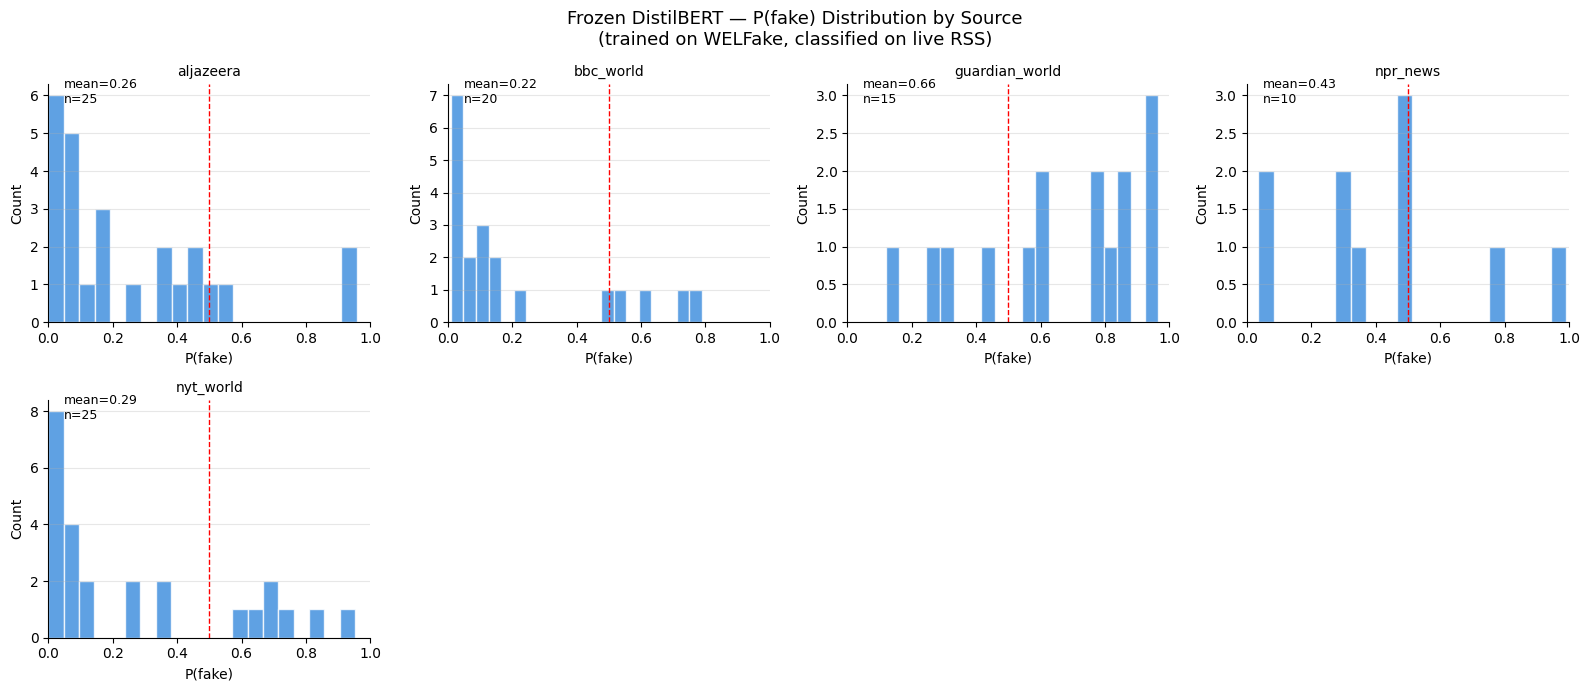

In [13]:
# ── P(fake) distribution by source ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sources = sorted(results_df['source'].unique())
n_sources = len(sources)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Frozen DistilBERT — P(fake) Distribution by Source\n'
             '(trained on WELFake, classified on live RSS)', fontsize=13)
axes = axes.flatten()

for i, source in enumerate(sources):
    subset = results_df[results_df['source'] == source]['p_fake']
    axes[i].hist(subset, bins=20, color='#378ADD', alpha=0.8, edgecolor='white')
    axes[i].axvline(x=0.5, color='red', linewidth=1, linestyle='--')
    axes[i].set_title(source, fontsize=10)
    axes[i].set_xlabel('P(fake)')
    axes[i].set_ylabel('Count')
    axes[i].set_xlim([0, 1])
    axes[i].text(0.05, 0.92, f'mean={subset.mean():.2f}\nn={len(subset)}',
                 transform=axes[i].transAxes, fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('frozen_distilbert_rss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Full article list sorted by P(fake) ───────────────────────────────────────
print('='*65)
print('ALL ARTICLES — sorted by P(fake) descending')
print('='*65)

sorted_df = results_df.sort_values('p_fake', ascending=False)

print('\nMost likely FAKE:')
for _, row in sorted_df.head(15).iterrows():
    print(f"  [{row['pred']:4}] P(fake)={row['p_fake']:.3f}  "
          f"source={row['source']}")
    print(f"         {row['title'][:80]}")

print('\nMost likely REAL:')
for _, row in sorted_df.tail(15).iterrows():
    print(f"  [{row['pred']:4}] P(fake)={row['p_fake']:.3f}  "
          f"source={row['source']}")
    print(f"         {row['title'][:80]}")

ALL ARTICLES — sorted by P(fake) descending

Most likely FAKE:
  [FAKE] P(fake)=0.991  source=npr_news
         Family influencers make the lifestyle look good. But kids pay the price, new boo
  [FAKE] P(fake)=0.965  source=guardian_world
         Podcast interviews of NSW couple jailed for abusing their daughter in the spotli
  [FAKE] P(fake)=0.957  source=aljazeera
         How Israel is destroying Lebanon’s water infrastructure
  [FAKE] P(fake)=0.953  source=nyt_world
         Threat of Evictions Darkens Russia’s Rosy Picture of Occupied Ukraine
  [FAKE] P(fake)=0.948  source=guardian_world
         Mouse plague hits WA grain farmers as numbers surge in SA: ‘You literally can’t 
  [FAKE] P(fake)=0.931  source=guardian_world
         British woman died in Ghana trying to recoup money from scammers, inquest told
  [FAKE] P(fake)=0.929  source=aljazeera
         Pakistan out of women’s football tournament in India over political strife
  [FAKE] P(fake)=0.873  source=guardian_world
    

In [15]:
# ── Save results ──────────────────────────────────────────────────────────────
ts  = datetime.now().strftime('%Y%m%d_%H%M')
out = f'/content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/frozen_distilbert_rss_{ts}.csv'
results_df[['source', 'title', 'published', 'word_count', 'p_fake', 'p_real', 'pred']]\
    .sort_values('p_fake', ascending=False)\
    .to_csv(out, index=False)
print(f'Results saved to {out}')

Results saved to /content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/frozen_distilbert_rss_20260422_2023.csv


## 9. Key Observations

Run this cell after reviewing the results above.

In [16]:
print('='*65)
print('KEY OBSERVATIONS')
print('='*65)

mean_pfake = results_df['p_fake'].mean()
pct_fake   = (results_df['pred'] == 'FAKE').mean()
pct_uncertain = ((results_df['p_fake'] > 0.3) & (results_df['p_fake'] < 0.7)).mean()

print(f"""
Frozen DistilBERT on live RSS news:
  Mean P(fake):          {mean_pfake:.3f}
  Predicted fake:        {pct_fake:.1%}
  Uncertain (0.3-0.7):   {pct_uncertain:.1%}

Architecture comparison:
  Fully fine-tuned DistilBERT: all 66M parameters updated on WELFake
    → learned WELFake publisher fingerprints and scraping artifacts
    → 99.4% WELFake accuracy, near 100% P(fake) on live news

  Frozen DistilBERT: only 1,538 parameters trained (head only)
    → transformer layers retain Wikipedia/BookCorpus representations
    → WELFake accuracy lower, but check whether live news distribution
      is more reasonable (less bimodal, more uncertain predictions)

What to look for in the results:
  - Is mean P(fake) lower and more centred than the fine-tuned model?
  - Is there more mass in the 0.2-0.8 range (genuine uncertainty)?
  - Are credible sources (Reuters, BBC, Guardian) scoring lower P(fake)?
  - Or is the frozen model also confidently wrong in the same direction?

If the frozen model still predicts high P(fake) across all sources,
it suggests the source bias problem is in the WELFake data itself —
even a linear classifier on top of general language representations
cannot escape it, because the features available at the CLS level
still reflect the training distribution's statistical properties.
""")
print('='*65)

KEY OBSERVATIONS

Frozen DistilBERT on live RSS news:
  Mean P(fake):          0.338
  Predicted fake:        31.6%
  Uncertain (0.3-0.7):   26.3%

Architecture comparison:
  Fully fine-tuned DistilBERT: all 66M parameters updated on WELFake
    → learned WELFake publisher fingerprints and scraping artifacts
    → 99.4% WELFake accuracy, near 100% P(fake) on live news

  Frozen DistilBERT: only 1,538 parameters trained (head only)
    → transformer layers retain Wikipedia/BookCorpus representations
    → WELFake accuracy lower, but check whether live news distribution
      is more reasonable (less bimodal, more uncertain predictions)

What to look for in the results:
  - Is mean P(fake) lower and more centred than the fine-tuned model?
  - Is there more mass in the 0.2-0.8 range (genuine uncertainty)?
  - Are credible sources (Reuters, BBC, Guardian) scoring lower P(fake)?
  - Or is the frozen model also confidently wrong in the same direction?

If the frozen model still predicts high